# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import os
import sys
import warnings

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [2]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # Select the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [3]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

In [4]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16695 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16695 non-null  float64
 1   Customer Lifetime Value         16695 non-null  float64
 2   EnrollmentType                  16695 non-null  int64  
 3   rejoined_program                16695 non-null  int64  
 4   Days_in_prog                    16695 non-null  float64
 5   Cancelled_program               16695 non-null  int64  
 6   Enrollment_year                 16695 non-null  int64  
 7   Enrollment_month                16695 non-null  int64  
 8   Location_cluster                16695 non-null  int64  
 9   TotalFlights                    16695 non-null  float64
 10  TotalDistance                   16695 non-null  float64
 11  TotalPointsAccumulated          16695 non-null  float64
 12  TotalPointsRedeemed            

In [5]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [6]:
people1 = people.copy()

In [7]:
for column in people1.columns:
    if column.startswith('Total_Spend_Month_'):
        people1[column] = np.sqrt(people1[column])

In [8]:
people_st_scl = StandardScaler().fit_transform(people1)
people_mm_scl = MinMaxScaler().fit_transform(people1)
people_rb_scl = RobustScaler().fit_transform(people1)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

## <h2 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 3: VALUE-BASED SEGMENTATION</h2>

Prepare the data

### Perspective 2 — Engagement Features

In this perspective, we analyze the **level of engagement** customers have with the loyalty program.  
Instead of focusing only on *who they are*, we start looking at **how they interact with the program over time**.

We selected the following variables:

```python
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]


In [9]:
# Perspective 2 — Engagement Features
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]

### Preparing the Engagement Dataset

Now that we defined the engagement variables, we extract them from the main dataset to build a dedicated clustering view.

```python
customer_engagement = people[engagement_features].copy()


In [10]:
# Prepare data
customer_engagement = people[engagement_features].copy()

In [11]:
# First look at distributions
customer_engagement.describe()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
count,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000
mean,1091.741659,92.816183,0.131710,0.231335,0.277600
std,743.947134,286.512522,0.075579,0.133497,0.336624
min,0.000000,1.018397,0.000000,0.000000,0.000000
25%,360.500000,1.018397,0.066347,0.161069,0.000000
50%,1014.000000,1.018397,0.151050,0.234052,0.214605
75%,1744.000000,2.003942,0.188311,0.304202,0.417202
max,2465.000000,999.000000,0.492603,1.052632,7.674566


From the summary statistics we saw clear outliers and skewed distributions in some engagement variables (e.g., Recency and Points Spent).
Because of this, RobustScaler is likely the best option, since it uses the median/IQR and is less affected by extreme values.

Still, we will test StandardScaler and Min-Max as well, to objectively compare cluster quality before deciding.

In [12]:
# Scaling
customer_engagement_st = StandardScaler().fit_transform(customer_engagement)
customer_engagement_rb = RobustScaler().fit_transform(customer_engagement)
customer_engagement_mm = MinMaxScaler().fit_transform(customer_engagement)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

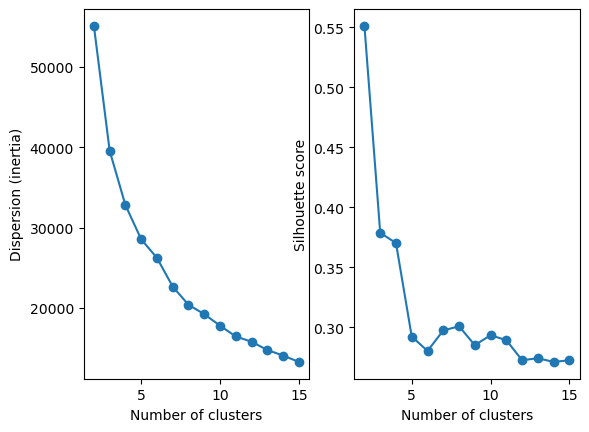

In [13]:
plot_inertia_and_silhouette(customer_engagement_st)

In [14]:
kmeans_st_scl = KMeans(n_clusters=10, random_state=42).fit(customer_engagement_st)
people['st_scaled_km_cluster10'] = kmeans_st_scl.predict(customer_engagement_st)

In [15]:
groupby_mean(people, 'st_scaled_km_cluster10')

st_scaled_km_cluster10,0,1,2,3,4,5,6,7,8,9
Income,38078.708498,37933.992749,37908.493948,38656.116907,37618.338353,37488.745073,36939.356902,38926.150538,36531.913580,37351.569463
Customer Lifetime Value,7875.859368,8329.786427,8003.783446,7824.832864,7974.343691,8098.203783,7987.594545,7738.620161,7149.506790,7652.331533
EnrollmentType,0.166008,0.027686,0.079320,0.016302,0.015395,0.158296,0.017957,0.075269,0.061728,0.155963
rejoined_program,0.018775,0.014502,0.000000,0.000000,0.000000,0.046408,0.000000,0.102151,0.074074,0.036042
Days_in_prog,397.024704,582.224786,852.219676,1863.665114,1928.628849,299.945963,1543.326599,221.564516,187.753086,386.605505
Cancelled_program,0.179842,0.615689,0.030646,0.025151,0.019411,0.208519,0.026375,0.204301,0.185185,0.176278
Enrollment_year,2020.246047,2017.800264,2019.167396,2016.365161,2016.187751,2020.420852,2017.255331,2020.473118,2020.654321,2020.263434
Enrollment_month,6.534585,7.259064,6.251095,6.672101,6.738286,7.007629,6.547699,7.973118,7.530864,6.644823
Location_cluster,2.438735,2.469347,2.434973,2.419190,2.475904,2.450095,2.423120,2.365591,2.308642,2.420052
TotalFlights,81.941601,0.000000,197.028329,175.455380,208.980254,56.080356,196.255163,18.266667,25.035802,73.399017


### Hierarchichal - Ward

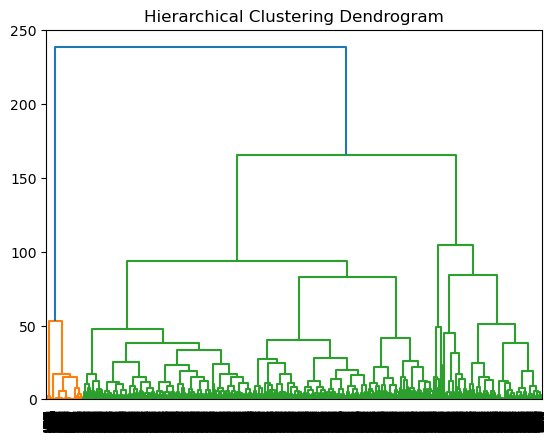

In [16]:
plot_dendrogram(customer_engagement_st, 'ward')

In [17]:
people['st_scaled_ward_cluster7'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 7
    ).fit_predict(customer_engagement_st)

In [18]:
groupby_mean(people, 'st_scaled_ward_cluster7')

st_scaled_ward_cluster7,0,1,2,3,4,5,6
Income,37933.992749,38141.740385,37523.728953,37878.466326,37708.412792,36943.286391,38070.405236
Customer Lifetime Value,8329.786427,8153.869615,7931.013105,7853.453646,7893.811023,7752.889207,8042.139445
EnrollmentType,0.027686,0.121795,0.174127,0.041338,0.015856,0.164497,0.082723
rejoined_program,0.014502,0.060897,0.042710,0.000000,0.000000,0.056805,0.000262
Days_in_prog,582.224786,221.224359,312.185626,1329.469577,1835.492785,288.487574,812.946859
Cancelled_program,0.615689,0.195513,0.199589,0.042267,0.024586,0.204734,0.042147
Enrollment_year,2017.800264,2020.647436,2020.425462,2017.825360,2016.441475,2020.467456,2019.256021
Enrollment_month,7.259064,7.000000,6.839014,6.522062,6.679316,7.066272,6.263874
Location_cluster,2.469347,2.407051,2.460780,2.441709,2.450027,2.404734,2.414398
TotalFlights,0.000000,38.513462,57.171581,178.037715,196.096954,47.806391,190.801649


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

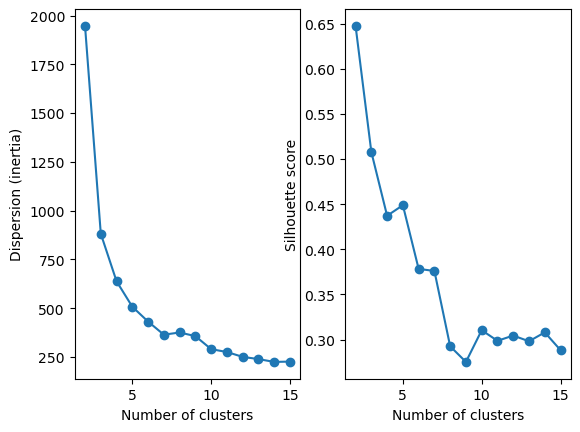

In [19]:
plot_inertia_and_silhouette(customer_engagement_mm)

In [20]:
kmeans_mm_scl = KMeans(n_clusters=6, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster6'] = kmeans_mm_scl.predict(customer_engagement_mm)

In [21]:
groupby_mean(people, 'mm_scaled_km_cluster6')

mm_scaled_km_cluster6,0,1,2,3,4,5
Income,37505.409767,37933.992749,38403.641406,37388.426712,37811.157242,37531.517184
Customer Lifetime Value,8019.110118,8329.786427,7899.869180,7935.156988,7916.568190,7760.936178
EnrollmentType,0.078585,0.027686,0.014844,0.017443,0.182780,0.159262
rejoined_program,0.000000,0.014502,0.000000,0.000000,0.036848,0.059514
Days_in_prog,749.706427,582.224786,2107.174479,1422.717782,286.854798,276.370495
Cancelled_program,0.038451,0.615689,0.009635,0.048946,0.186793,0.197821
Enrollment_year,2019.491440,2017.800264,2015.700781,2017.524082,2020.497264,2020.505448
Enrollment_month,5.609037,7.259064,6.783854,6.979432,6.960598,6.996647
Location_cluster,2.428010,2.469347,2.455469,2.424889,2.444728,2.440905
TotalFlights,188.706203,0.000000,195.669427,193.875137,64.402043,49.927829


### Hierarchichal - Ward

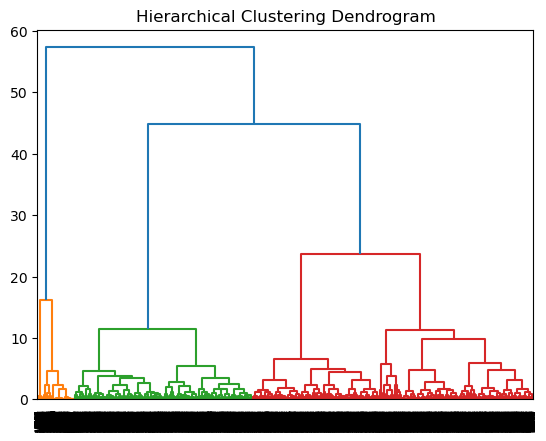

In [22]:
plot_dendrogram(customer_engagement_mm, 'ward')

In [23]:
people['mm_scaled_ward_cluster8'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 8
    ).fit_predict(customer_engagement_mm)

In [24]:
groupby_mean(people, 'mm_scaled_ward_cluster8')

mm_scaled_ward_cluster8,0,1,2,3,4,5,6,7
Income,37351.095068,38110.250304,38033.374474,38659.095705,39497.013514,37666.046332,37262.661126,37480.930980
Customer Lifetime Value,7952.207999,7935.852738,7664.995975,7881.007298,9063.696306,8203.973305,7967.366689,7982.225279
EnrollmentType,0.016679,0.180933,0.110799,0.013527,0.018018,0.029344,0.018657,0.213383
rejoined_program,0.000000,0.001217,0.099579,0.000000,0.000000,0.016988,0.000000,0.051633
Days_in_prog,1031.588039,440.822718,190.677419,2176.791343,2323.783784,283.671815,1658.859227,244.545311
Cancelled_program,0.043126,0.090872,0.204769,0.003720,0.000000,0.721236,0.043080,0.221812
Enrollment_year,2018.640457,2020.227181,2020.692847,2015.524856,2015.031532,2018.274903,2016.902985,2020.605901
Enrollment_month,6.488921,6.286004,7.319776,6.657423,7.815315,7.163707,6.748982,6.711802
Location_cluster,2.415058,2.471805,2.309958,2.473115,2.450450,2.472587,2.408752,2.485248
TotalFlights,195.194758,130.448357,27.438990,195.389144,0.000000,0.000000,196.620014,45.701791


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling Andre</h3>

### K-Means

### Testing Different Values of K (Behavioral / Engagement Clustering)

We now evaluate how many clusters make sense for the *engagement* dimension.

First, we visualized inertia and silhouette scores:

```python
plot_inertia_and_silhouette(customer_engagement_rb)


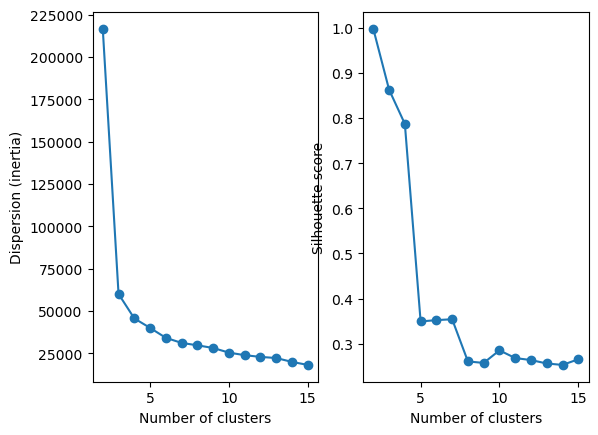

In [25]:
plot_inertia_and_silhouette(customer_engagement_rb)

### Running K-Means with Multiple K Values

To understand how the data behaves under different segmentation granularities,
we run K-Means repeatedly using several candidate values for **K**.


In [26]:
for k in [3, 4, 5]:
    kmeans_rb_scl = KMeans(n_clusters=k, random_state=42).fit(customer_engagement_rb)
    people[f"rb_scaled_km_cluster{k}"] = kmeans_rb_scl.predict(customer_engagement_rb)


In [27]:
print("K=3")
display(groupby_mean(people, "rb_scaled_km_cluster3"))

print("K=4")
display(groupby_mean(people, "rb_scaled_km_cluster4"))

print("K=5")
display(groupby_mean(people, "rb_scaled_km_cluster5"))


K=3


rb_scaled_km_cluster3,0,1,2
Income,36874.705882,37933.992749,37806.230561
Customer Lifetime Value,7688.976765,8329.786427,7941.322290
EnrollmentType,0.010695,0.027686,0.075329
rejoined_program,0.002674,0.014502,0.011781
Days_in_prog,649.274064,582.224786,1168.242204
Cancelled_program,0.915775,0.615689,0.029453
Enrollment_year,2018.568182,2017.800264,2018.281774
Enrollment_month,6.475936,7.259064,6.612959
Location_cluster,2.340909,2.469347,2.443243
TotalFlights,81.697594,0.000000,162.396764


K=4


rb_scaled_km_cluster4,0,1,2,3
Income,36701.773963,37933.992749,37657.394901,38188.022127
Customer Lifetime Value,7758.623190,8329.786427,7964.259520,7870.717778
EnrollmentType,0.010014,0.027686,0.068801,0.090650
rejoined_program,0.002861,0.014502,0.009342,0.017606
Days_in_prog,649.327611,582.224786,1229.073959,1013.454199
Cancelled_program,0.917024,0.615689,0.005060,0.099215
Enrollment_year,2018.536481,2017.800264,2018.125243,2018.673091
Enrollment_month,6.390558,7.259064,6.594687,6.670236
Location_cluster,2.351931,2.469347,2.445115,2.435641
TotalFlights,80.128898,0.000000,170.848239,141.053652


K=5


rb_scaled_km_cluster5,0,1,2,3,4
Income,36807.388769,37933.992749,37628.454943,38251.563910,36942.413706
Customer Lifetime Value,7704.081382,8329.786427,7965.109663,7882.349272,7770.401827
EnrollmentType,0.019438,0.027686,0.067561,0.094690,0.007614
rejoined_program,0.002160,0.014502,0.009141,0.018327,0.002538
Days_in_prog,694.440605,582.224786,1239.909886,1009.455592,624.187817
Cancelled_program,0.909287,0.615689,0.004868,0.066494,0.906091
Enrollment_year,2018.844492,2017.800264,2018.095281,2018.707942,2018.324873
Enrollment_month,6.451404,7.259064,6.597615,6.615132,6.911168
Location_cluster,2.267819,2.469347,2.443915,2.445254,2.416244
TotalFlights,107.137149,0.000000,172.024421,141.099624,58.235533


In [28]:
cols_k3 = engagement_features + ["rb_scaled_km_cluster3"]
cols_k4 = engagement_features + ["rb_scaled_km_cluster4"]
cols_k5 = engagement_features + ["rb_scaled_km_cluster5"]

In [29]:
print("K=3")
display(groupby_mean(people[cols_k3], "rb_scaled_km_cluster3"))

print("K=4")
display(groupby_mean(people[cols_k4], "rb_scaled_km_cluster4"))

print("K=5")
display(groupby_mean(people[cols_k5], "rb_scaled_km_cluster5"))


K=3


rb_scaled_km_cluster3,0,1,2
Days_in_prog,649.274064,582.224786,1168.242204
RecencyInMonths,16.139271,999.000000,1.525364
Flights_per_day,0.074610,0.001990,0.148308
PctFlightsWithCompanions,0.261450,0.003088,0.253769
PctPointsSpent,0.293820,0.002836,0.305644


K=4


rb_scaled_km_cluster4,0,1,2,3
Days_in_prog,649.327611,582.224786,1229.073959,1013.454199
RecencyInMonths,16.637340,999.000000,1.096782,2.660754
Flights_per_day,0.073177,0.001990,0.156026,0.128816
PctFlightsWithCompanions,0.262569,0.003088,0.270032,0.213911
PctPointsSpent,0.293681,0.002836,0.338740,0.224614


K=5


rb_scaled_km_cluster5,0,1,2,3,4
Days_in_prog,694.440605,582.224786,1239.909886,1009.455592,624.187817
RecencyInMonths,10.916280,999.000000,1.093340,2.394826,19.878416
Flights_per_day,0.097842,0.001990,0.157100,0.128858,0.053183
PctFlightsWithCompanions,0.252298,0.003088,0.271897,0.211109,0.267806
PctPointsSpent,0.300362,0.002836,0.343478,0.216292,0.288104


Choosing the number of clusters (Behavioral perspective)

To decide the best value of K, we tested K-Means with K = 3, 4 and 5 using the engagement features.
Across all values, we consistently observed one clear segment of non-active customers (very high recency, almost no flights, almost no points spent). This shows that the clustering is capturing a real pattern in the data.

However, the structure of the remaining clusters changed:

K = 3 was too coarse — active customers with different engagement levels were mixed together.

K = 5 started to over-segment the data, creating clusters that were very similar to each other and harder to interpret.

K = 4 provided the best balance: it separates customers into four intuitive behavioral groups (inactive, low, moderate and high engagement) while remaining simple to explain from a business perspective.

For this reason, we continue with K = 4.

### Hierarchichal - Ward

### Hierarchical Clustering — Dendrogram (Ward Linkage)

To complement the K-Means analysis, we also explore the structure of the data
using **hierarchical clustering**.

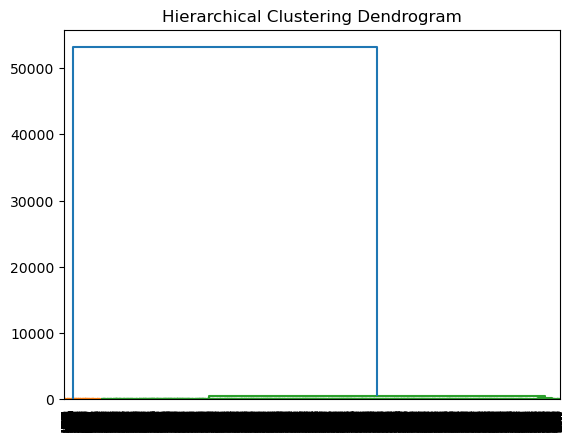

In [30]:
plot_dendrogram(customer_engagement_rb, 'ward')

### Using the Dendrogram to Select Candidate Cluster Counts

After inspecting the dendrogram generated with Ward linkage, we observed a few
large vertical jumps, suggesting that the data may naturally separate into a
small number of groups.

To evaluate those possibilities more systematically, we tested hierarchical
clustering with different values of \(k\):

In [31]:
for k in [3, 4, 5, 6]:
    people[f"rb_scaled_ward_cluster{k}"] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_rb)

    print(f"K = {k}")
    display(groupby_mean(people, f"rb_scaled_ward_cluster{k}").head(10))


K = 3


rb_scaled_ward_cluster3,0,1,2
Income,36976.672566,37933.992749,37809.953412
Customer Lifetime Value,7694.709934,8329.786427,7943.717072
EnrollmentType,0.013274,0.027686,0.075872
rejoined_program,0.002212,0.014502,0.011910
Days_in_prog,686.201327,582.224786,1171.575312
Cancelled_program,0.892699,0.615689,0.021227
Enrollment_year,2018.579646,2017.800264,2018.277918
Enrollment_month,6.696903,7.259064,6.600462
Location_cluster,2.342920,2.469347,2.444234
TotalFlights,88.107633,0.000000,162.872762


K = 4


rb_scaled_ward_cluster4,0,1,2,3
Income,37809.953412,36400.591584,37442.1460,37933.992749
Customer Lifetime Value,7943.717072,7565.992525,7798.7136,8329.786427
EnrollmentType,0.075872,0.017327,0.0100,0.027686
rejoined_program,0.011910,0.000000,0.0040,0.014502
Days_in_prog,1171.575312,744.940594,638.7400,582.224786
Cancelled_program,0.021227,0.868812,0.9120,0.615689
Enrollment_year,2018.277918,2018.794554,2018.4060,2017.800264
Enrollment_month,6.600462,6.960396,6.4840,7.259064
Location_cluster,2.444234,2.311881,2.3680,2.469347
TotalFlights,162.872762,111.913119,68.8728,0.000000


K = 5


rb_scaled_ward_cluster5,0,1,2,3,4
Income,37442.1460,38119.912038,37698.986395,37933.992749,36400.591584
Customer Lifetime Value,7798.7136,7908.181151,7956.439141,8329.786427,7565.992525
EnrollmentType,0.0100,0.064576,0.079916,0.027686,0.017327
rejoined_program,0.0040,0.003455,0.014937,0.014502,0.000000
Days_in_prog,638.7400,1308.295775,1122.628580,582.224786,744.940594
Cancelled_program,0.9120,0.058995,0.007706,0.615689,0.868812
Enrollment_year,2018.4060,2017.909912,2018.409666,2017.800264,2018.794554
Enrollment_month,6.4840,6.399150,6.672534,7.259064,6.960396
Location_cluster,2.3680,2.443263,2.444582,2.469347,2.311881
TotalFlights,68.8728,174.600213,158.674265,0.000000,111.913119


K = 6


rb_scaled_ward_cluster6,0,1,2,3,4,5
Income,37698.986395,38119.912038,36123.782456,37933.992749,36400.591584,39189.744186
Customer Lifetime Value,7956.439141,7908.181151,7829.498912,8329.786427,7565.992525,7757.905163
EnrollmentType,0.079916,0.064576,0.014035,0.027686,0.017327,0.004651
rejoined_program,0.014937,0.003455,0.007018,0.014502,0.000000,0.000000
Days_in_prog,1122.628580,1308.295775,664.435088,582.224786,744.940594,604.679070
Cancelled_program,0.007706,0.058995,0.912281,0.615689,0.868812,0.911628
Enrollment_year,2018.409666,2017.909912,2018.536842,2017.800264,2018.794554,2018.232558
Enrollment_month,6.672534,6.399150,6.256140,7.259064,6.960396,6.786047
Location_cluster,2.444582,2.443263,2.298246,2.469347,2.311881,2.460465
TotalFlights,158.674265,174.600213,94.022807,0.000000,111.913119,35.534419


Using hierarchical clustering (Ward), we tested cut levels between 3 and 6 clusters. 

K = 4 produced the best structure: non-travellers were clearly separated, and the remaining customers formed intuitive engagement tiers (low, moderate, high).
Larger K values started to over-segment similar customers, while smaller K mixed distinct behaviors together.
Therefore, we selected Ward with K = 4 for the engagement perspective.

In [32]:
people['rb_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(customer_engagement_rb)

In [33]:
groupby_mean(people, 'rb_scaled_ward_cluster4')

rb_scaled_ward_cluster4,0,1,2,3
Income,37809.953412,36400.591584,37442.146000,37933.992749
Customer Lifetime Value,7943.717072,7565.992525,7798.713600,8329.786427
EnrollmentType,0.075872,0.017327,0.010000,0.027686
rejoined_program,0.011910,0.000000,0.004000,0.014502
Days_in_prog,1171.575312,744.940594,638.740000,582.224786
Cancelled_program,0.021227,0.868812,0.912000,0.615689
Enrollment_year,2018.277918,2018.794554,2018.406000,2017.800264
Enrollment_month,6.600462,6.960396,6.484000,7.259064
Location_cluster,2.444234,2.311881,2.368000,2.469347
TotalFlights,162.872762,111.913119,68.872800,0.000000


# <span style="color:#0097b2">1. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization 1

### Cluster Visualization (Perspective 1 — Profile Features)

To better understand how the K-Means clusters behave in the high-dimensional
space, we projected the customers into **2D using UMAP**.  

We visualised three candidate clustering solutions:

- `st_scaled_km_cluster10`  (StandardScaler, K = 10)
- `mm_scaled_km_cluster6`   (Min-Max Scaler, K = 6)
- `rb_scaled_km_cluster4`   (Robust Scaler, K = 4)

UMAP does **not influence the clustering** — it only helps us *see*
whether clusters form compact and separated regions.

From the plots we observed that:

- Some solutions (e.g., K = 10) generated **many small fragmented clusters**
  that overlap heavily — difficult to interpret from a business point of view.
- Min-Max scaling with K = 6 showed slightly more structure, but still
  produced clusters that blended together.
- Robust-scaled K = 4 created **cleaner, more stable groups** with clearer
  separation across the UMAP space.

These visual diagnostics helped us narrow down which clustering setups
were worth exploring further in the next steps.


In [34]:
clusters_km = ['st_scaled_km_cluster10', 'mm_scaled_km_cluster6', 'rb_scaled_km_cluster4']

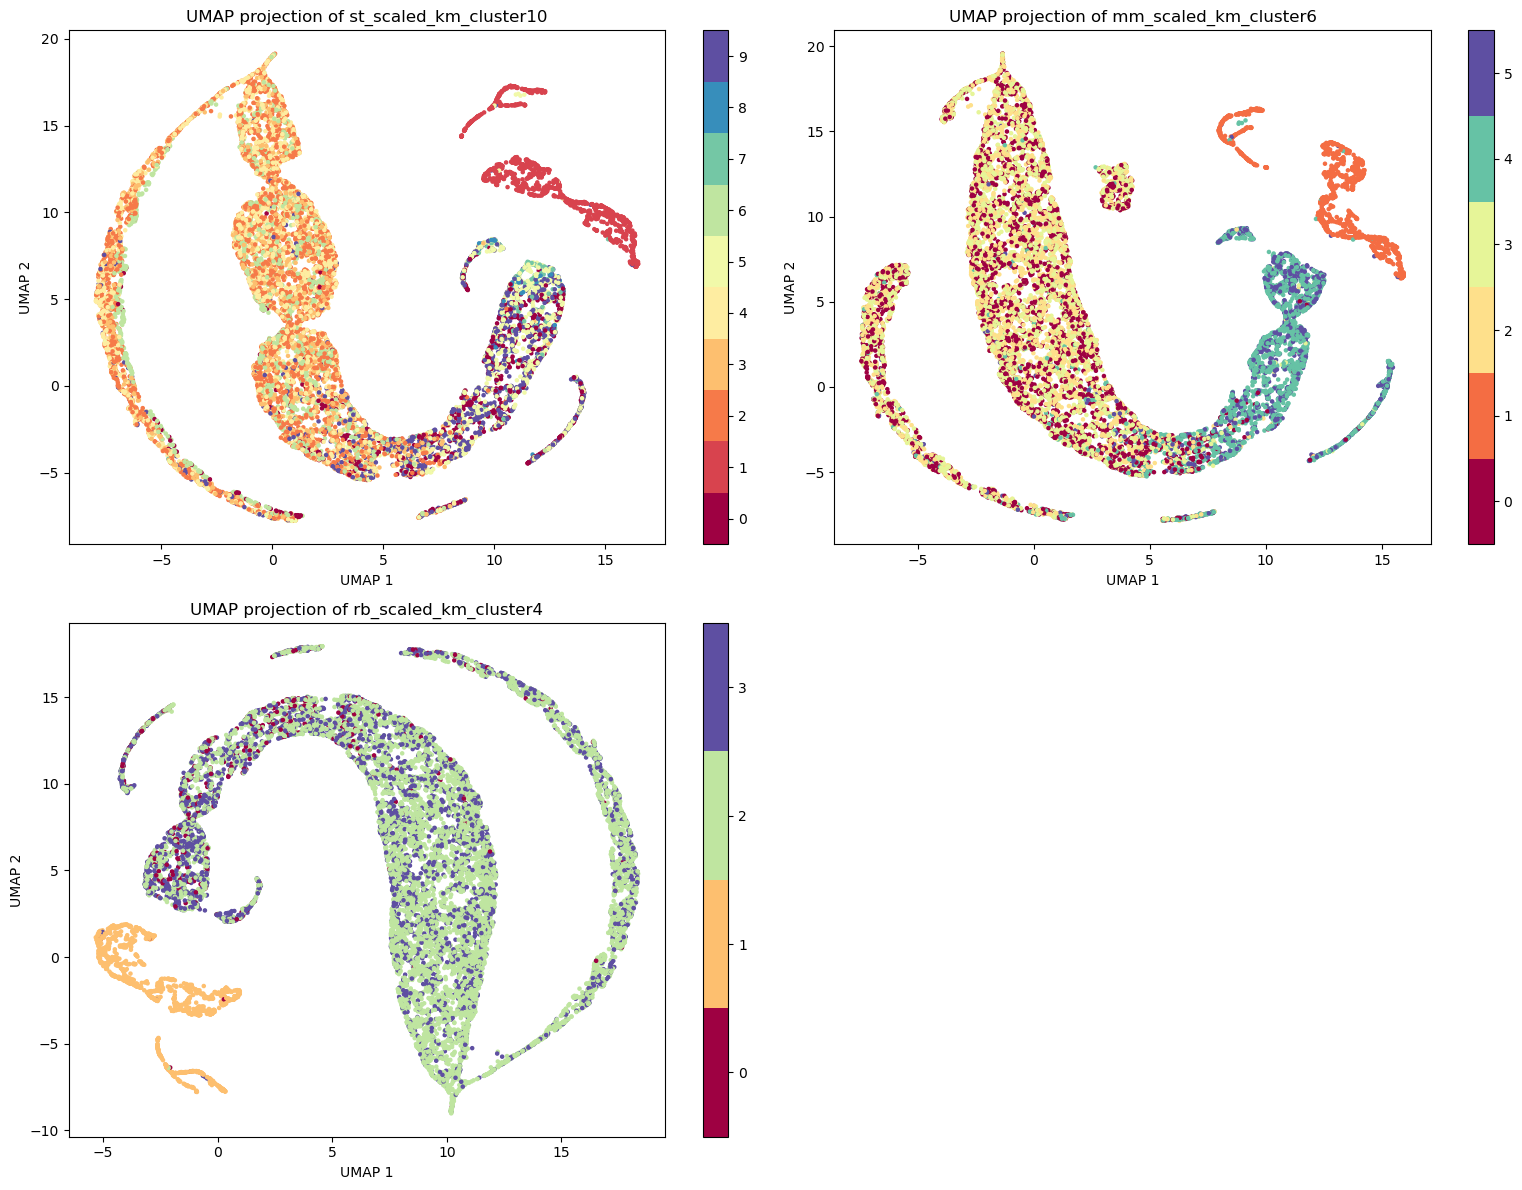

In [35]:
plot_umap_projections(people, clusters_km)

In [36]:
cluster_ward = ['st_scaled_ward_cluster7', 'mm_scaled_ward_cluster8', 'rb_scaled_ward_cluster4']

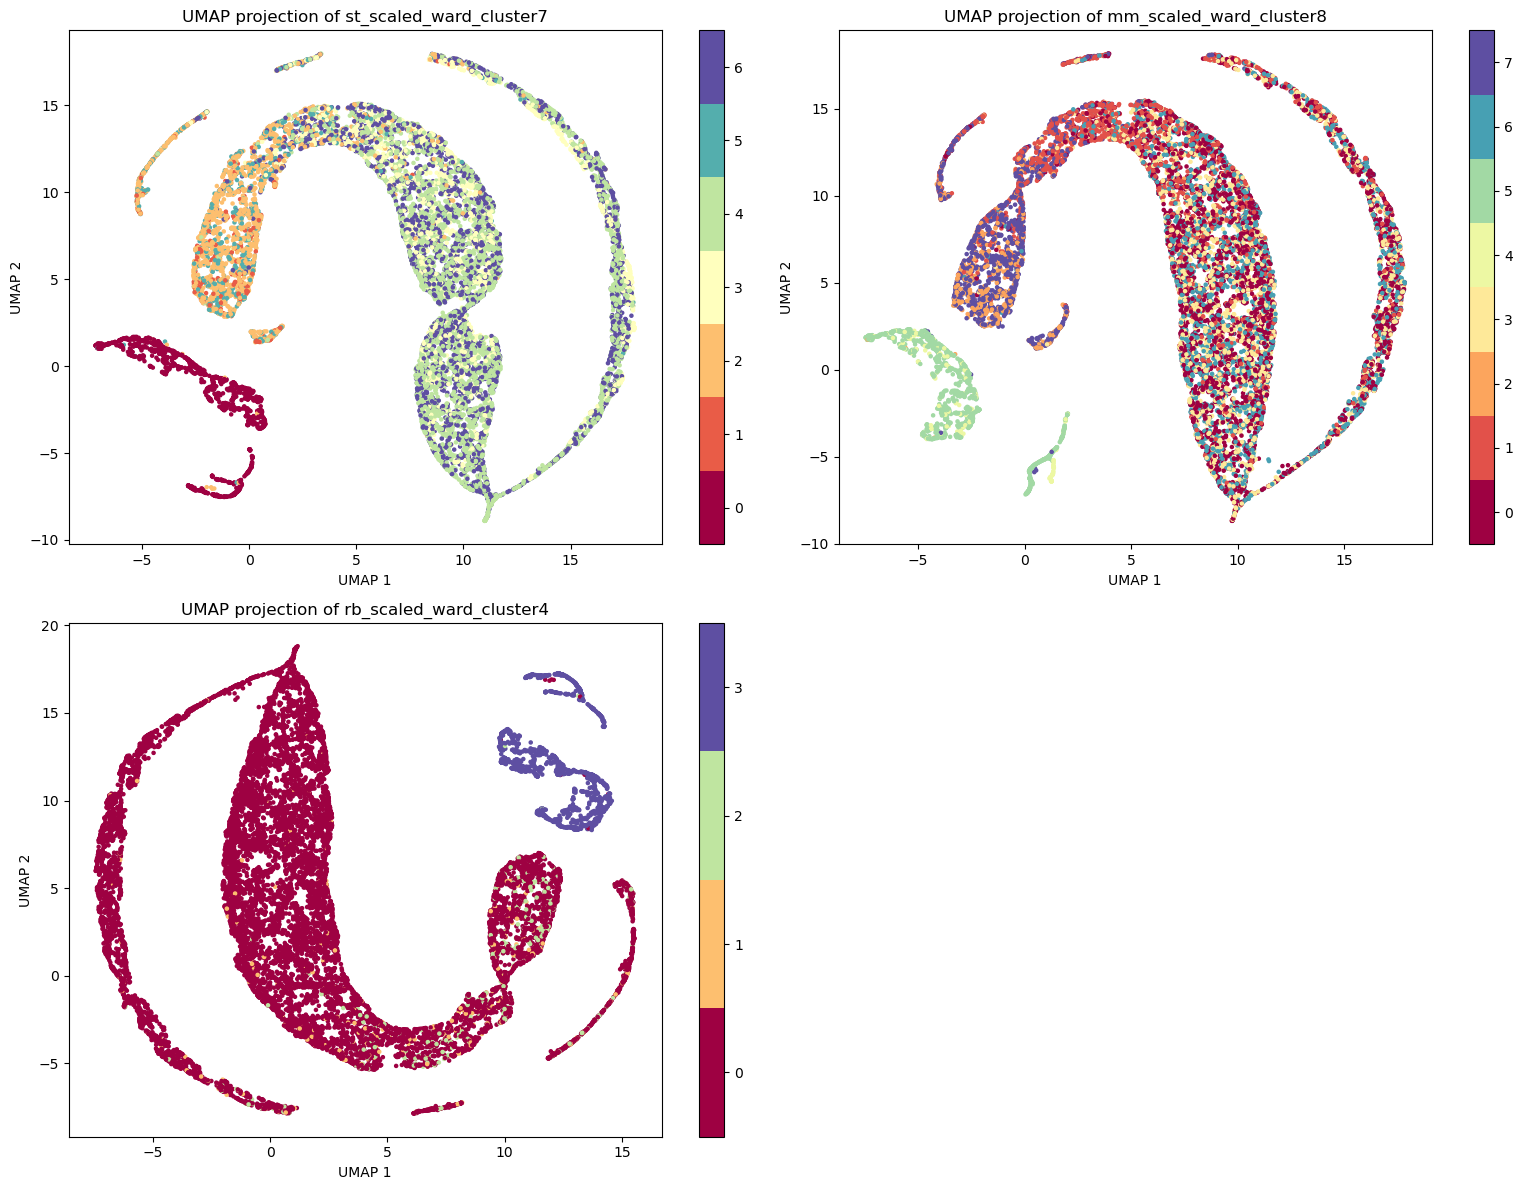

In [37]:
plot_umap_projections(people, cluster_ward)

In [38]:
groupby_mean(people, 'rb_scaled_ward_cluster4')

rb_scaled_ward_cluster4,0,1,2,3
Income,37809.953412,36400.591584,37442.146000,37933.992749
Customer Lifetime Value,7943.717072,7565.992525,7798.713600,8329.786427
EnrollmentType,0.075872,0.017327,0.010000,0.027686
rejoined_program,0.011910,0.000000,0.004000,0.014502
Days_in_prog,1171.575312,744.940594,638.740000,582.224786
Cancelled_program,0.021227,0.868812,0.912000,0.615689
Enrollment_year,2018.277918,2018.794554,2018.406000,2017.800264
Enrollment_month,6.600462,6.960396,6.484000,7.259064
Location_cluster,2.444234,2.311881,2.368000,2.469347
TotalFlights,162.872762,111.913119,68.872800,0.000000


### Cluster Visualization (Ward Hierarchical — Profile Perspective)

Next, we inspected the hierarchical clustering (Ward linkage) results using UMAP.

We visualised three candidate models:

- `st_scaled_ward_cluster7`
- `mm_scaled_ward_cluster8`
- `rb_scaled_ward_cluster4`

Again, UMAP is only a **visual aid** — the clustering itself happens in the
full feature space.

From the plots, we noticed that:

- The models with **7 and 8 clusters** produced several small, scattered
  groups that overlapped heavily. These clusters were difficult to interpret
  and did not correspond to distinct customer behaviours.
- The Robust-scaled Ward solution with **K = 4** created
  **well-defined, compact regions**. Each cluster appeared stable and
  separated, which suggests stronger underlying structure in the data.

To validate the interpretation, we examined the mean values of each feature
within the 4 clusters. The result showed clear differences in spending,
recency and participation — confirming that the segments represent
meaningfully different customer profiles.

Based on both visual separation and interpretability,  
we selected **Ward + Robust scaling with 4 clusters** as the preferred
solution for this first (profile-based) perspective.


#### Cluster Extraction 1

### Cluster Extraction — Removing Non-Travelers

From the Ward clustering with \(K = 4\), one segment emerged with a very
distinct pattern:

- almost **no flights**
- essentially **no distance travelled**
- very low or zero points activity

This group corresponds to customers who are *technically in the program*,
but **do not actively travel**. In business terms, they behave fundamentally
differently from the rest of the base.

Because our next steps focus on understanding *travel behaviour*, we isolate
this segment before continuing.


In [39]:
# Filter the DataFrame based on cluster labels
non_travelers = people[people['rb_scaled_ward_cluster4'] == 3]

In [40]:
# List of cluster labels to exclude
exclude_clusters = [3]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered1 = people[~people['rb_scaled_ward_cluster4'].isin(exclude_clusters)]

In [41]:
people_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,st_scaled_ward_cluster7,mm_scaled_km_cluster6,mm_scaled_ward_cluster8,rb_scaled_km_cluster3,rb_scaled_km_cluster4,rb_scaled_km_cluster5,rb_scaled_ward_cluster3,rb_scaled_ward_cluster4,rb_scaled_ward_cluster5,rb_scaled_ward_cluster6
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,6,0,0,2,2,2,2,0,2,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,4,2,3,2,2,2,2,0,2,0
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,6,0,0,2,3,3,2,0,1,1
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,6,3,0,2,2,2,2,0,2,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,4,2,6,2,3,3,2,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,5,2,0,0,4,0,2,0,5
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,4,3,6,2,3,3,2,0,1,1
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,6,4,1,2,2,2,2,0,2,0


In [42]:
people_filtered1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15178 entries, 100018 to 999986
Data columns (total 67 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          15178 non-null  float64
 1   Customer Lifetime Value         15178 non-null  float64
 2   EnrollmentType                  15178 non-null  int64  
 3   rejoined_program                15178 non-null  int64  
 4   Days_in_prog                    15178 non-null  float64
 5   Cancelled_program               15178 non-null  int64  
 6   Enrollment_year                 15178 non-null  int64  
 7   Enrollment_month                15178 non-null  int64  
 8   Location_cluster                15178 non-null  int64  
 9   TotalFlights                    15178 non-null  float64
 10  TotalDistance                   15178 non-null  float64
 11  TotalPointsAccumulated          15178 non-null  float64
 12  TotalPointsRedeemed            

In [43]:
people_filtered1 = people_filtered1.loc[:, ~people_filtered1.columns.str.startswith(("st_", "mm_", "rb_"))]

In [44]:
people_filtered1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15178 entries, 100018 to 999986
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          15178 non-null  float64
 1   Customer Lifetime Value         15178 non-null  float64
 2   EnrollmentType                  15178 non-null  int64  
 3   rejoined_program                15178 non-null  int64  
 4   Days_in_prog                    15178 non-null  float64
 5   Cancelled_program               15178 non-null  int64  
 6   Enrollment_year                 15178 non-null  int64  
 7   Enrollment_month                15178 non-null  int64  
 8   Location_cluster                15178 non-null  int64  
 9   TotalFlights                    15178 non-null  float64
 10  TotalDistance                   15178 non-null  float64
 11  TotalPointsAccumulated          15178 non-null  float64
 12  TotalPointsRedeemed            

### Cleaning intermediate clustering labels

After removing the non-traveler segment, the dataset still contained all of
the **previous clustering columns** (those starting with `st_`, `mm_`, and `rb_`).

These labels were only useful for the *first stage* of segmentation, and
keeping them could bias or confuse the next clustering steps.

So, we drop all intermediate cluster columns:


In [45]:
people['rb_scaled_ward_cluster4'].value_counts()

rb_scaled_ward_cluster4
0    14274
3     1517
2      500
1      404
Name: count, dtype: int64

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

#### Re-Scaling Data 2

## Second Examination — Re-clustering After Removing Non-Travelers

At this stage, we removed the *Non-Travelers* group from the population.  
The remaining customers still represent multiple behavior profiles, so we
perform a **new round of clustering** to further differentiate them.

We start with the filtered dataset:

```python
people_filtered1


In [46]:
people_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,1,0,0,0,0,0,1,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,0,1,0,0,0,0,1,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,1,0,0,0,0,0,1,0


### Transforming Monthly Spending Variables

We create a working copy of the filtered dataset:

Monthly spending variables (Total_Spend_Month_*) are typically right-skewed:
most customers spend small amounts, while a few spend very large amounts.

Highly skewed variables can dominate distance-based clustering, so we apply a
square-root transformation to reduce the influence of extreme values

This keeps the overall structure of the data (higher spenders are still higher),
but compresses large values, helping the clustering algorithm better detect
meaningful patterns instead of simply grouping customers by spending magnitude.

In [47]:
people_filtered11 = people_filtered1.copy()

for column in people_filtered11.columns:
    if column.startswith('Total_Spend_Month_'):
        people_filtered11[column] = np.sqrt(people_filtered11[column])

### Scaling the Data for Clustering

Clustering algorithms such as K-Means and hierarchical clustering are
distance-based.  
If variables are on different scales (e.g., dollars vs. percentages), features
with larger ranges dominate the result.

So we scale the data in two different ways

Min-Max scaling squeezes everything into 
[0,1].
While this can work, it is very sensitive to outliers: a single extreme
customer would stretch the whole scale and compress everyone else.

Because engagement and spending metrics contain heavy tails, Min-Max would hide
important structure. RobustScaler and StandardScaler preserve variation more
reliably in this context.

In summary: we keep two scaled versions (standardized and robust) and compare
clustering results to ensure our insights are not driven by scaling choices.

In [48]:
people_filtered1_st_scl = StandardScaler().fit_transform(people_filtered11)
people_filtered1_rb_scl = RobustScaler().fit_transform(people_filtered11)

#### Cluster Modelling 2

### Cluster evaluation — Standard Scaled features

We first evaluate clustering performance using the **standard-scaled dataset**.

- **Inertia (left)** decreases gradually with no sharp elbow, meaning there is no single “perfect” K.
- **Silhouette score (right)** drops significantly after **K = 2** and then fluctuates at relatively low values.

This suggests that:

- very large K values are unnecessary,
- reasonable candidates lie mainly between **K = 2 and K = 4**.

At this stage, the plots act as **guidance**, and we will combine them with dendrograms and UMAP visualizations before deciding on the final K.


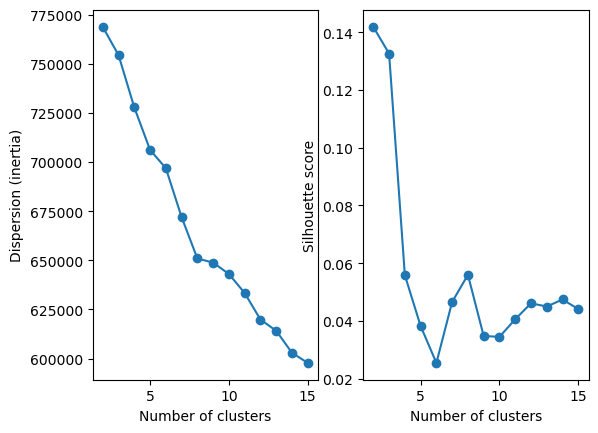

In [49]:
plot_inertia_and_silhouette(people_filtered1_st_scl)

### Cluster evaluation — Robust Scaled features

We repeat the analysis using **robust-scaled features**, which reduce the influence of outliers.

- **Inertia** again decreases smoothly, showing no strong elbow.
- **Silhouette scores** remain high for small K values and then steadily decline as K increases.

The pattern is consistent with the standard-scaled version:  
smaller values of **K (around 2–4)** produce the clearest structure, while larger K values add complexity without improving cluster separation.

As before, we treat these results as guidance and rely on additional diagnostics (dendrograms + UMAP + business interpretation) to finalize the clustering decision.


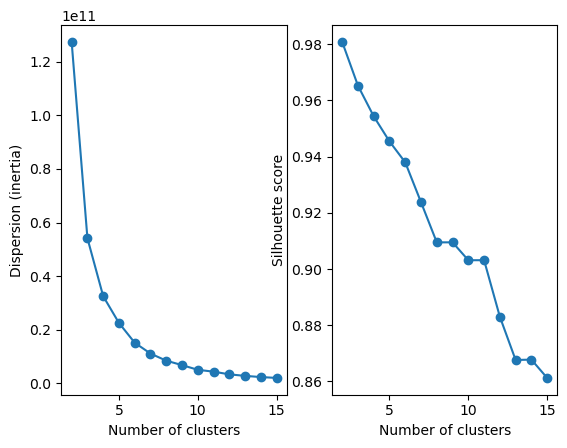

In [50]:
plot_inertia_and_silhouette(people_filtered1_rb_scl)

### Hierarchical structure (StandardScaler + Ward)

We plot a dendrogram using Ward linkage on the standardized features.

The dendrogram shows clear large jumps in merge distance, suggesting a few
well-separated groups before clusters begin to merge aggressively. This confirms
that the data still contains meaningful hierarchical structure even after
removing the non-travellers, and it helps us identify reasonable cut levels for
the number of clusters to test next.


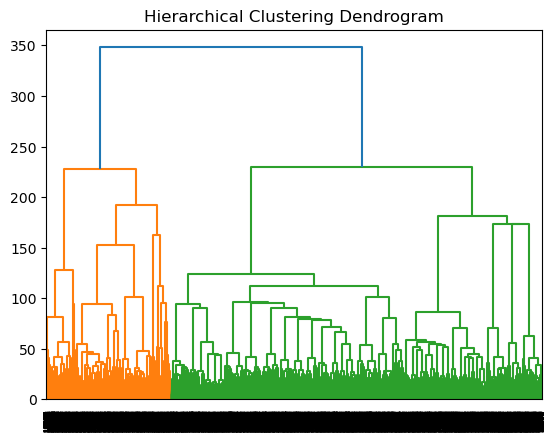

In [51]:
plot_dendrogram(people_filtered1_st_scl, 'ward')

### Hierarchical structure (RobustScaler + Ward)

Here we repeat the dendrogram using Robust scaling.

Because RobustScaler reduces the impact of outliers, the tree is more “compressed”
at the bottom and the large merges occur later. This indicates that the dataset
still contains some extreme observations, but their influence is now moderated —
making cluster boundaries more stable.

We will use this plot together with inertia/silhouette to choose candidate values
for the number of clusters.


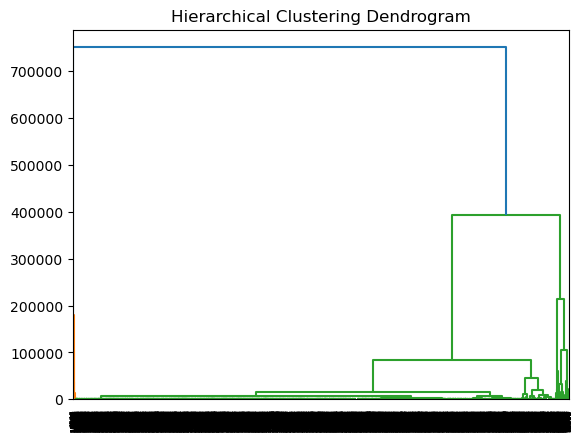

In [52]:
plot_dendrogram(people_filtered1_rb_scl, 'ward')

#### Cluster Visualization 2

### Agglomerative (Ward): selecting candidate cluster cuts

Based on the dendrogram and inertia/silhouette curves, we applied Ward
hierarchical clustering with two different cut levels:

- **K = 3** on the Robust-scaled data  
- **K = 4** on the Standard-scaled data  

These values correspond to natural “break points” in the hierarchy: they split
the large branches without fragmenting the structure into too many small,
hard-to-interpret groups.  
We keep both, as each provides a different granular view that we will compare
visually next.


In [53]:
people_filtered1['filter1_rb_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(people_filtered1_rb_scl)

people_filtered1['filter1_st_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(people_filtered1_st_scl)

### K-Means baselines for comparison

To complement Ward clustering, we fitted K-Means on the same scaled datasets:

- **K = 5** on Robust-scaled features
- **K = 2** on Standard-scaled features

These values come from the elbow/silhouette inspection:  
K = 5 provides some additional segmentation without heavy fragmentation, while  
K = 2 reveals the highest-level split remaining in the data.

We will not decide purely from metrics — instead we compare all models using UMAP
to see which ones align best with meaningful structure.


In [54]:
kmeans_rb_scl = KMeans(n_clusters=5, random_state=42).fit(people_filtered1_rb_scl)
people_filtered1['filter1_rb_scaled_km_cluster5'] = kmeans_rb_scl.predict(people_filtered1_rb_scl)

kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(people_filtered1_st_scl)
people_filtered1['filter1_st_scaled_km_cluster2'] = kmeans_st_scl.predict(people_filtered1_st_scl)

### Visual validation of clusters (UMAP)

We project each clustering solution onto a 2-D UMAP embedding.

UMAP allows us to visually check whether clusters map onto coherent regions
instead of being randomly scattered. Across the plots, Ward-K=4 and
K-Means-K=2 show the clearest separation, while the other candidates either
collapse most customers into a single region or over-fragment small groups.

This visual evidence guides which segmentation paths are worth continuing.


In [55]:
cluster_filter1 = ['filter1_rb_scaled_ward_cluster3', 'filter1_st_scaled_ward_cluster4', 'filter1_rb_scaled_km_cluster5', 'filter1_st_scaled_km_cluster2']

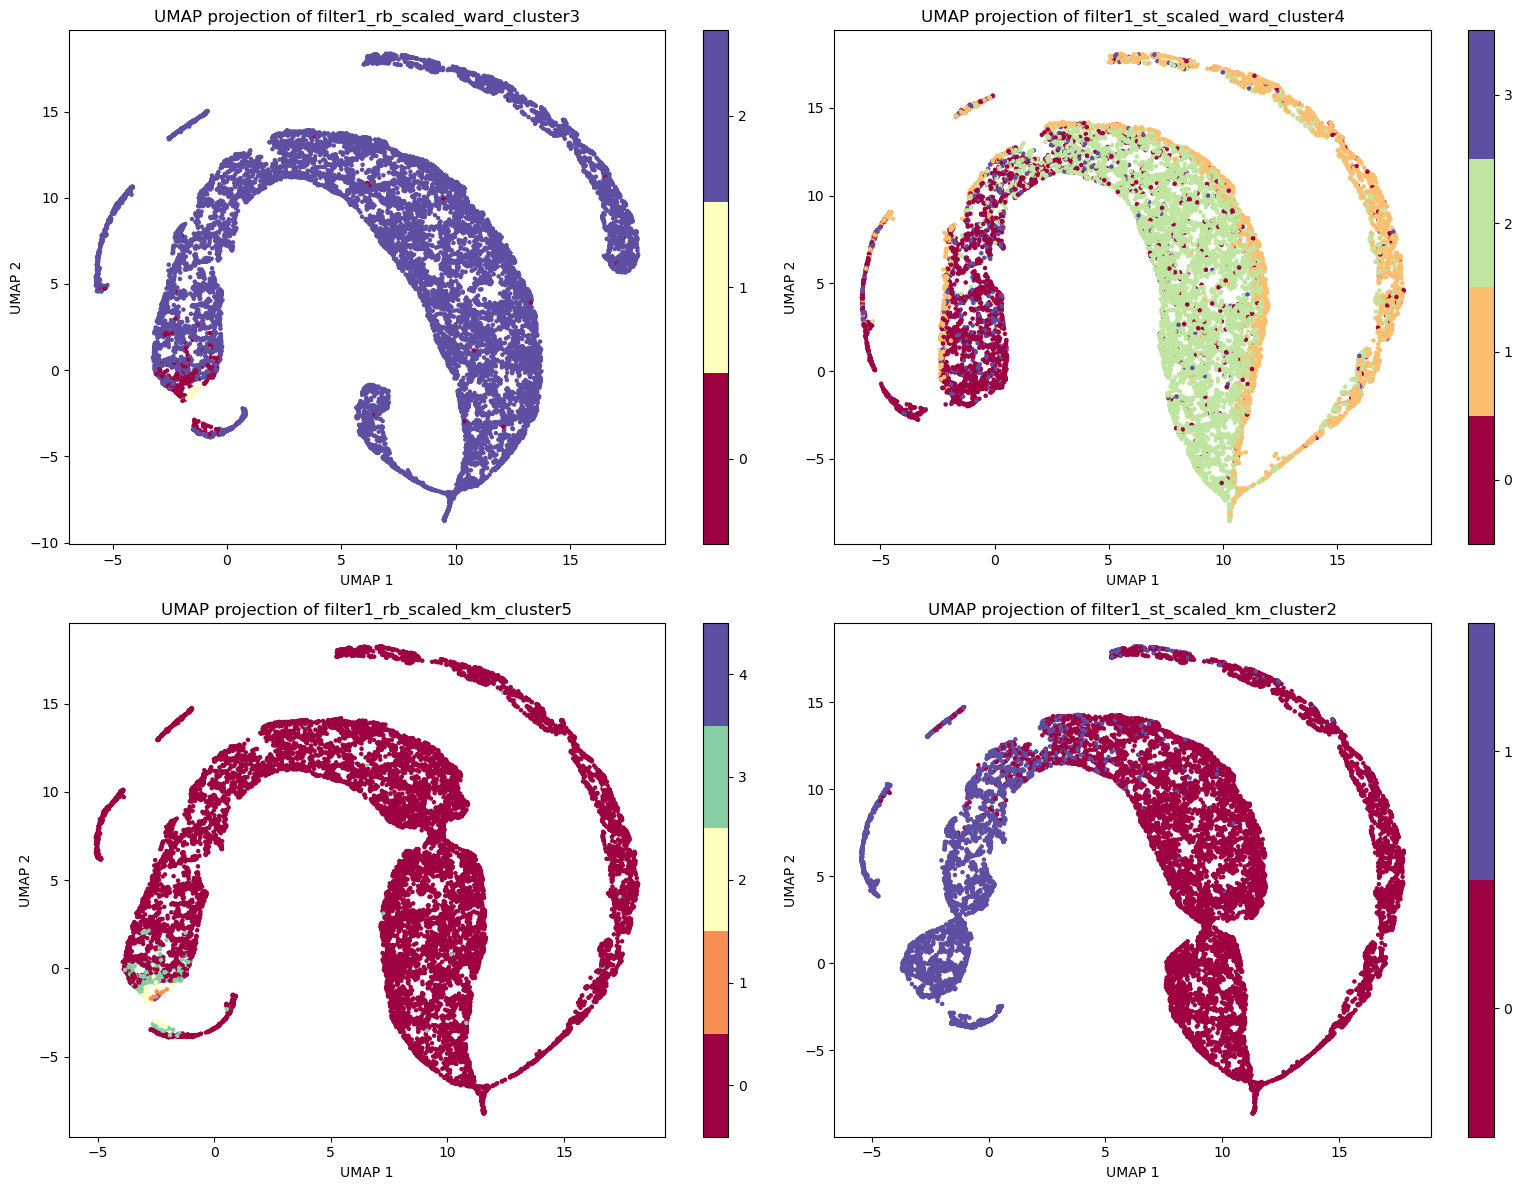

In [56]:
plot_umap_projections(people_filtered1, cluster_filter1)

### Interpreting the 2-cluster solution

We summarize feature averages for each cluster. The split is very clear:

- **Cluster 0** → long program tenure, high flight activity, high points usage  
- **Cluster 1** → shorter tenure, low activity, significantly fewer flights and
  fewer redeemed points

In business terms, the first group corresponds to **loyal / highly engaged
customers**, while the second group is **much less engaged and at higher risk of
churn**.

This confirms that the 2-cluster solution captures a meaningful top-level
behavioral distinction that we will exploit in the next filtering step.


In [57]:
groupby_mean(people_filtered1, 'filter1_st_scaled_km_cluster2')

filter1_st_scaled_km_cluster2,0,1
Income,37722.817552,37857.841793
Customer Lifetime Value,7958.440727,7852.041748
EnrollmentType,0.040777,0.153700
rejoined_program,0.000000,0.040797
Days_in_prog,1446.584291,352.451376
Cancelled_program,0.019431,0.212761
Enrollment_year,2017.527915,2020.292694
Enrollment_month,6.506842,6.864564
Location_cluster,2.441434,2.429791
TotalFlights,195.244527,62.671869


#### Cluster Extraction 2

### Cluster Extraction — Step 2 (removing highly engaged customers)

From the 2-cluster K-Means model, Cluster **0** clearly represented the
most engaged / loyal customers (high activity, long tenure, frequent points
usage).

Since our objective is to further analyze the *remaining* population,
we temporarily remove this segment:

1. We isolate Cluster 0 → `loyal`
2. We create a new dataset (`people_filtered2`) excluding those records

This allows us to apply a second round of clustering only on the less-engaged
customers, revealing finer sub-segments (e.g., at-risk vs. inactive).


In [59]:
# Filter the DataFrame based on cluster labels
loyal = people_filtered1[people_filtered1['filter1_st_scaled_km_cluster2'] == 0]

In [60]:
# List of cluster labels to exclude
exclude_clusters = [0]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered2 = people_filtered1[~people_filtered1['filter1_st_scaled_km_cluster2'].isin(exclude_clusters)]

Before moving to the second clustering round, we remove all previously
generated clustering columns (`st_`, `mm_`, `rb_` prefixes).

These columns are *model artifacts* (labels from earlier clustering steps),
and keeping them could bias the next models.  

By cleaning them here, we ensure that the next clustering stage is based
only on the **original behavioral and demographic features**.


In [61]:
people_filtered2 = people_filtered2.loc[:, ~people_filtered2.columns.str.startswith(("st_", "mm_", "rb_"))]

In [62]:
people_filtered2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,filter1_rb_scaled_ward_cluster3,filter1_st_scaled_ward_cluster4,filter1_rb_scaled_km_cluster5,filter1_st_scaled_km_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100504,59762.0,8807.61,0,0,243.0,1,2020,7,1,106.6,...,0,0,0,1,0,0,2,3,0,1
100590,51840.0,34090.04,1,0,297.0,0,2021,3,0,28.0,...,0,0,0,0,1,0,2,0,0,1
101547,0.0,5619.69,0,0,447.0,0,2020,10,1,58.0,...,0,0,0,0,1,0,2,1,0,1
101644,19683.0,8382.63,0,0,47.0,0,2021,11,1,6.0,...,0,0,1,0,1,0,0,0,2,1
101768,52423.0,13916.93,0,0,119.0,0,2021,9,2,6.0,...,0,0,0,0,0,1,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999758,0.0,18690.34,0,0,131.0,0,2021,8,2,16.0,...,0,0,0,0,0,1,0,0,3,1
999788,33397.0,8409.07,0,0,243.0,1,2020,2,1,79.8,...,0,0,0,0,1,0,2,3,0,1
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,0,0,0,0,1,0,0,3,3,1


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

#### Re-Scaling Data 2

### Re-scaling the filtered dataset (Round 2)

After removing the Loyal segment, we repeat the same preparation pipeline
for the remaining customers.

1. We create a working copy of the dataset.
2. For the monthly spend variables (`Total_Spend_Month_*`), we again apply a
   square-root transformation — this reduces the impact of extreme spenders
   while preserving the relative order of customers.
3. We rescale all features using two different scalers:
   - **StandardScaler** (mean = 0, variance = 1)
   - **RobustScaler** (less sensitive to outliers)

This ensures that the second round of clustering is performed on a clean,
comparable feature space without letting very large values dominate the model.


In [63]:
people_filtered2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,filter1_rb_scaled_ward_cluster3,filter1_st_scaled_ward_cluster4,filter1_rb_scaled_km_cluster5,filter1_st_scaled_km_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100504,59762.0,8807.61,0,0,243.0,1,2020,7,1,106.6,...,0,0,0,1,0,0,2,3,0,1
100590,51840.0,34090.04,1,0,297.0,0,2021,3,0,28.0,...,0,0,0,0,1,0,2,0,0,1
101547,0.0,5619.69,0,0,447.0,0,2020,10,1,58.0,...,0,0,0,0,1,0,2,1,0,1
101644,19683.0,8382.63,0,0,47.0,0,2021,11,1,6.0,...,0,0,1,0,1,0,0,0,2,1
101768,52423.0,13916.93,0,0,119.0,0,2021,9,2,6.0,...,0,0,0,0,0,1,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999758,0.0,18690.34,0,0,131.0,0,2021,8,2,16.0,...,0,0,0,0,0,1,0,0,3,1
999788,33397.0,8409.07,0,0,243.0,1,2020,2,1,79.8,...,0,0,0,0,1,0,2,3,0,1
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,0,0,0,0,1,0,0,3,3,1


In [64]:
people_filtered22 = people_filtered2.copy()

for column in people_filtered22.columns:
    if column.startswith('Total_Spend_Month_'):
        people_filtered22[column] = np.sqrt(people_filtered22[column])

In [65]:
people_filtered2_st_scl = StandardScaler().fit_transform(people_filtered22)
people_filtered2_rb_scl = RobustScaler().fit_transform(people_filtered22)

#### Cluster Modelling 2

### Cluster Modelling — Round 2 (Standard-scaled data)

We evaluate different values of **K** using two diagnostics:

- **Inertia (Elbow method)** — how compact the clusters are.
- **Silhouette score** — how well-separated the clusters are.

For this filtered dataset (after removing Loyal customers), the elbow curve
flattens gradually, while the silhouette values remain relatively low —
suggesting that the structure is weaker than in the previous round.

Still, there are a few local peaks (around K ≈ 2–4), which we will examine
next using both K-Means and hierarchical clustering, combined with visual
inspection (UMAP) and business interpretability.


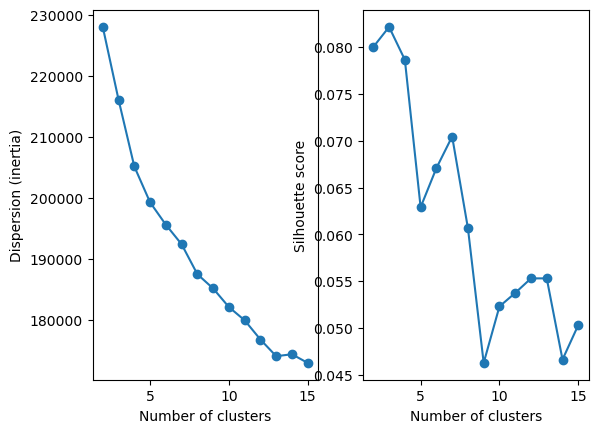

In [66]:
plot_inertia_and_silhouette(people_filtered2_st_scl)

### Cluster Modelling — Round 2 (Robust-scaled data)

We repeat the same evaluation using **RobustScaler**, which reduces the
influence of outliers.

The overall pattern is similar:

- Inertia decreases smoothly without a very sharp elbow.
- Silhouette scores are modest, but we again observe reasonable candidates
around **K ≈ 2–4**.

Since both scaling strategies tell a consistent story, we proceed by
testing these small values of K with multiple clustering algorithms, and we
will prioritize **interpretability and business meaning** when deciding the
final segmentation.


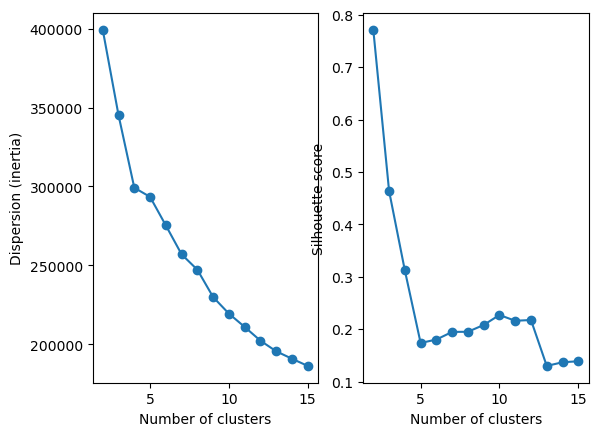

In [67]:
plot_inertia_and_silhouette(people_filtered2_rb_scl)

### Hierarchical clustering (Ward) — visual inspection

We also applied **hierarchical clustering with Ward linkage** and inspected
the dendrogram to understand how groups merge as the distance threshold
increases.

A few clear splits appear early, indicating that the data naturally forms
a **small number of well-separated clusters**. Beyond that point, merges
become gradual, meaning that further subdivisions would mainly split
already-similar customers.

This confirms the signal we observed earlier:  
values around **K ≈ 2–4** capture most of the meaningful structure without
over-segmenting the population.


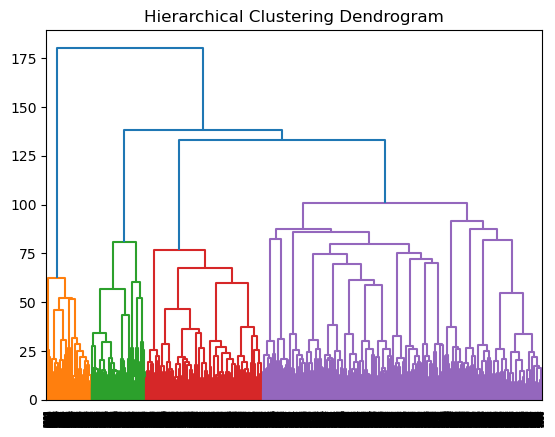

In [68]:
plot_dendrogram(people_filtered2_st_scl, 'ward')

### Hierarchical clustering (Ward) — dendrogram (Robust-scaled data)

Here we apply hierarchical clustering using **Ward linkage** on the dataset
scaled with **RobustScaler**.

The dendrogram shows one dominant split at a large distance (a clearly
separated group), while most remaining merges occur gradually at smaller
distances. This indicates that:

- there is **one strongly distinct cluster**, and  
- the remaining customers form only a few progressively similar sub-groups.

Combined with the inertia and silhouette results, this suggests that using a
**small number of clusters (around 2–3)** is appropriate at this refinement
stage, rather than forcing many micro-segments.


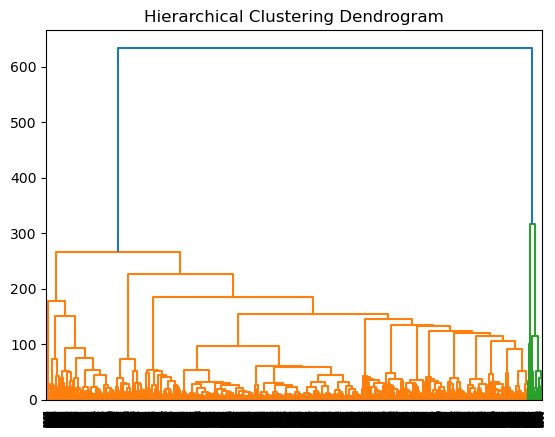

In [69]:
plot_dendrogram(people_filtered2_rb_scl, 'ward')

#### Cluster Visualization 2

### Hierarchical clustering (refinement step)

At this stage we run hierarchical clustering again, but now only on the
customers who remained after removing the loyal group.

Why these values of K?

From the dendrograms and silhouette curves, the Robust-scaled data
clearly suggested three meaningful groups (one dominant cluster and two
smaller sub-segments).

For the Standard-scaled data, the structure collapsed earlier, and the
clearest and most stable split was simply two clusters.

Choosing small K values here is intentional:
we are refining the segmentation step-by-step, rather than forcing too many
artificial sub-clusters at once.

In [70]:
people_filtered2['filter1_rb_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(people_filtered2_rb_scl)

people_filtered2['filter1_st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(people_filtered2_st_scl)

### K-Means refinement (visual validation)

Next, we also apply K-Means on the refined dataset to see whether a simpler
partition emerges consistently across algorithms

In [71]:
kmeans_rb_scl = KMeans(n_clusters=2, random_state=42).fit(people_filtered2_rb_scl)
people_filtered2['filter1_rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(people_filtered2_rb_scl)

kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(people_filtered2_st_scl)
people_filtered2['filter1_st_scaled_km_cluster2'] = kmeans_st_scl.predict(people_filtered2_st_scl)

We then project all clustering solutions into UMAP space to visually compare
their separation:

In [72]:
cluster_filter2 = ['filter1_rb_scaled_ward_cluster3', 'filter1_st_scaled_ward_cluster2', 'filter1_rb_scaled_km_cluster2', 'filter1_st_scaled_km_cluster2']

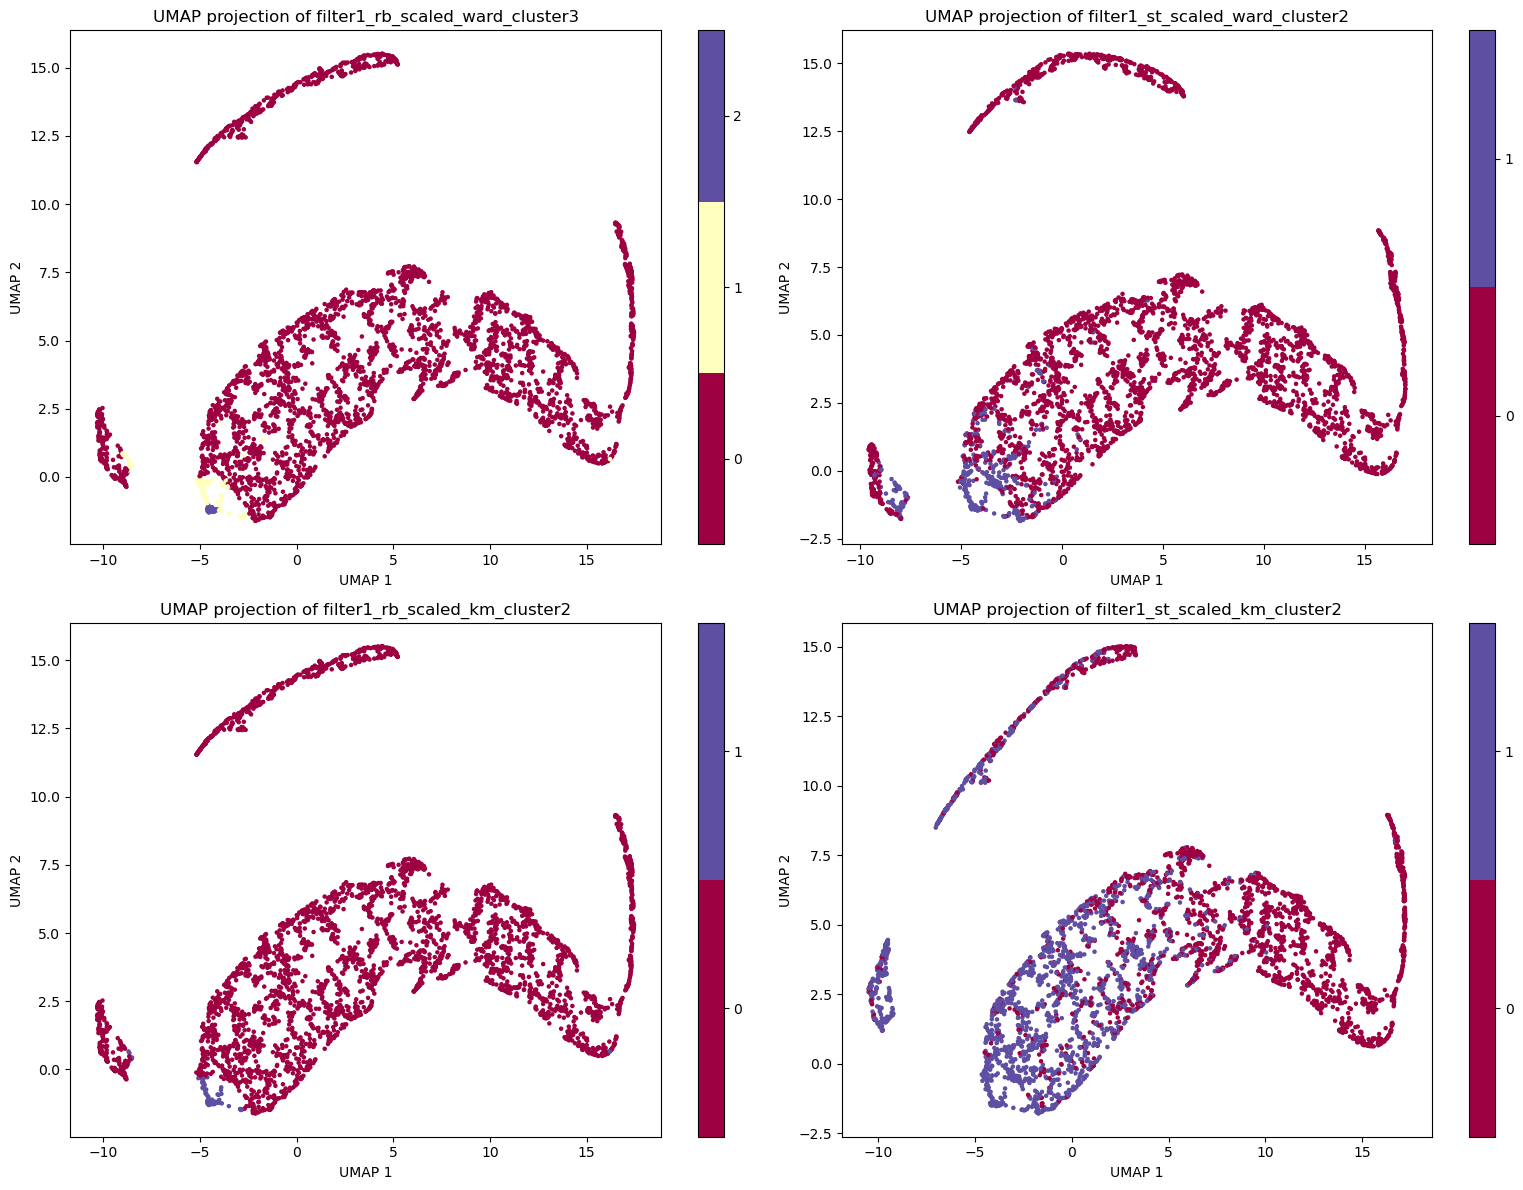

In [73]:
plot_umap_projections(people_filtered2, cluster_filter2)

Across both Ward and K-Means, we repeatedly see the same structure:
one smaller, clearly differentiated group and one larger group with
more internal variation.

This consistency suggests that the clusters are not an artifact of a
single algorithm, but reflect stable patterns in the remaining customer base.

### Interpreting the second-stage clusters

To understand what the two clusters represent, we compared their feature
averages

In [74]:
groupby_mean(people_filtered2, 'filter1_st_scaled_km_cluster2')

filter1_st_scaled_km_cluster2,0,1
Income,36866.492028,39001.083759
Customer Lifetime Value,7793.868379,7919.128299
EnrollmentType,0.063773,0.257406
rejoined_program,0.001329,0.086313
Days_in_prog,490.744907,192.968846
Cancelled_program,0.337467,0.068948
Enrollment_year,2019.721435,2020.951481
Enrollment_month,7.221878,6.452503
Location_cluster,2.411426,2.450970
TotalFlights,88.158946,33.279724


**Cluster interpretation**

**Cluster 0** shows:

- much longer program tenure (higher `Days_in_prog`)
- more flights, distance and redeemed points  
- higher recency (they engaged more in the past, but not recently)  
- slightly lower cancellations  

**Cluster 1** shows:

- more recent enrollments (higher `Enrollment_year`)
- fewer flights and points overall  
- lower time in program but more recent activity  
- slightly higher probability of cancellation  

**In other words:**

- **Cluster 0 → formerly active members (declining engagement)**
- **Cluster 1 → newer / light users (still building history)**


#### Cluster Extraction 2

### Cluster Extraction 

At this stage we isolate the two clusters obtained previously:

- `Cluster 0` → **At-Risk customers** (previously active, declining engagement)  
- `Cluster 1` → **Inactive / light users** (recent arrivals, low history)



In [75]:
# Filter the DataFrame based on cluster labels
at_risk = people_filtered2[people_filtered2['filter1_st_scaled_km_cluster2'] == 0]
inactive = people_filtered2[people_filtered2['filter1_st_scaled_km_cluster2'] == 1]

Since these clusters represent meaningful behavioral groups, we remove them
from the working dataset to continue segmenting the remaining customers:

In [76]:
# List of cluster labels to exclude
exclude_clusters = [0, 1]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered3 = people_filtered2[~people_filtered2['filter1_st_scaled_km_cluster2'].isin(exclude_clusters)]

In [77]:
people_filtered3 = people_filtered3.loc[:, ~people_filtered3.columns.str.startswith(("st_", "mm_", "rb_"))]

The result (people_filtered3) is empty, meaning that all remaining customers
were already classified into meaningful segments at this stage.
No additional clustering is necessary for this branch.

In [78]:
people_filtered3

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,filter1_rb_scaled_ward_cluster3,filter1_st_scaled_ward_cluster4,filter1_rb_scaled_km_cluster5,filter1_st_scaled_km_cluster2,filter1_st_scaled_ward_cluster2,filter1_rb_scaled_km_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,


### Final Customer Segmentation Assignment

After completing all clustering phases, we map each customer to one of the
final business segments:

- **Non_Travelers** – customers who never fly (structurally different group)  
- **Loyal_Customers** – high engagement and consistent program usage  
- **At_Risk_Customers** – previously active, but engagement is declining  
- **Inactive_Customers** – newer / light users with limited activity  

We create the column and assign the labels:

In [79]:
people['segment'] = 'Unassigned'

people.loc[non_travelers.index, 'segment'] = 'Non_Travelers'
people.loc[loyal.index, 'segment'] = 'Loyal_Customers'
people.loc[at_risk.index, 'segment'] = 'At_Risk_Customers'
people.loc[inactive.index, 'segment'] = 'Inactive_Customers'

### Segment Distribution and Encoding

Before moving forward, we check how customers are distributed across the four
final segments:


In [80]:
people['segment'].value_counts()

segment
Loyal_Customers       10962
At_Risk_Customers      2258
Inactive_Customers     1958
Non_Travelers          1517
Name: count, dtype: int64

This confirms that our segmentation meaningfully splits the population into
distinct groups (loyal, at-risk, inactive and non-travelers).

To make the segment usable in downstream analytics and modeling, we convert the
categorical label into one-hot encoded variables:

In [81]:
segment_dummies = pd.get_dummies(
    people['segment'],
    prefix='seg',
    dtype=int
)

### Append the Encoded Segments to the Dataset

We now merge the one-hot encoded segment columns back into the main dataset.

This keeps all original features while adding four new binary indicators for the
final customer segments.

In [82]:
people = pd.concat([people, segment_dummies], axis=1)

Since the segment is now represented by one-hot encoded variables, the original
categorical column is no longer needed:

In [83]:
people.drop(columns=['segment'], inplace=True)

In [84]:
people = people.loc[:, ~people.columns.str.startswith(("st_", "mm_", "rb_"))]

Displaying `people` confirms the final structure of the dataset:  
all original variables remain, and four new binary fields indicate each
customer’s assigned segment.

Key added columns:

- `seg_Loyal_Customers`  
- `seg_At_Risk_Customers`  
- `seg_Inactive_Customers`  
- `seg_Non_Travelers`

Each row belongs to exactly **one** segment (value 1), with the rest set to 0.

In [85]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,seg_At_Risk_Customers,seg_Inactive_Customers,seg_Loyal_Customers,seg_Non_Travelers
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,0,0,1,0,0,0,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,0,0,1,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,0,0,1,0,0,0,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,0,0,1,0,0,0,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,0,0,1,0,0,0,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,0,0,1,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,0,0,1,0,0,0,0,1


## Summary — Engagement-Based Customer Segmentation

In this perspective, we segmented customers using engagement features such as:

- Flights and distance traveled  
- Recency of activity  
- Program tenure  
- Spending and redemption behavior  
- Loyalty participation  

We applied clustering iteratively to progressively isolate meaningful behavioral segments.

---

### 1. Initial clustering (full population)

- We first ran engagement-based clustering on the full dataset.  
- A very clear group of **Non-Travelers** emerged (customers who are enrolled but never fly or use points).  
- These customers were:
  - behaviorally distinct  
  - not informative for differentiating engagement patterns among actual travelers  

We **removed Non-Travelers** from further modeling and kept them as their own segment.

---

### 2. Second iteration (active customers only)

On the remaining active customers, we:

- Re-scaled features using **StandardScaler** and **RobustScaler**  
- Evaluated cluster structures with:
  - inertia (elbow analysis)  
  - silhouette scores  
  - hierarchical dendrograms (Ward)  
  - UMAP projections for visual validation  

This analysis revealed a stable and interpretable group of **Loyal Customers** with:

- long tenure  
- frequent flights  
- high points accumulation and redemption  
- consistent engagement across months  

These customers were labeled as **Loyal Customers** and kept as a key segment.

---

### 3. Final refinement (remaining active members)

The remaining customers were clustered again and split into two groups:

- **Cluster 0**:  
  - longer tenure  
  - higher number of flights and distance  
  - more points accumulated and redeemed  
  - higher recency (engaged in the past, but less recently)

- **Cluster 1**:  
  - more recent enrollment  
  - fewer flights and points overall  
  - shorter time in the program but more recent activity  
  - slightly higher cancellation propensity  

Interpretation:

- **Cluster 0 ≈ At-Risk Customers**  
  Previously active members whose engagement is now declining.

- **Cluster 1 ≈ Inactive Customers**  
  Newer or lighter users who are still building their relationship with the program.

Both groups remain in the dataset but represent different CRM priorities.

---

### Final Segments (4 clusters)

We end up with **four engagement-based segments**:

| Segment              | Description                                                                 |
|----------------------|-----------------------------------------------------------------------------|
| Non-Travelers        | Enrolled but never engage with flights or loyalty features.                |
| Inactive Customers   | Low recent activity, short tenure, minimal usage so far.                   |
| At-Risk Customers    | Previously active users showing declining engagement.                      |
| Loyal Customers      | High tenure, frequent flights, high redemption and consistent engagement.  |

---

### Business Implications

This segmentation enables:

- Targeted **activation campaigns** for Non-Travelers  
- Stronger **onboarding and education** for Inactive Customers  
- **Re-engagement / win-back strategies** for At-Risk Customers  
- **Retention and loyalty reinforcement** for Loyal Customers  

Overall, the final clusters are:

- behaviorally meaningful  
- stable across methods  
- easy to explain to business stakeholders  
- directly actionable for CRM and marketing strategies.
